# Thư Viện


In [396]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# Dữ liệu

In [397]:


cyberdata= pd.read_csv(r'C:\Users\ADMIN\OneDrive - National Economics University\NEU\y3 neu\bigdata analysis\Big-data\Cleaned_Global_Cybersecurity_Threats_2015-2024.csv')
list(cyberdata.head())


['Country',
 'Year',
 'Attack Type',
 'Target Industry',
 'Financial Loss (in Million $)',
 'Number of Affected Users',
 'Attack Source',
 'Security Vulnerability Type',
 'Defense Mechanism Used',
 'Incident Resolution Time (in Hours)']

In [398]:
cyberdata

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169.0,Hacker Group,Unpatched Software,Vpn,63.0
1,China,2019,Ransomware,Retail,62.19,295961.0,Unknown,Unpatched Software,Firewall,71.0
2,India,2017,Man-In-The-Middle,It,38.65,605895.0,Hacker Group,Weak Passwords,Vpn,36.0
3,Uk,2024,Ransomware,Telecommunications,41.44,659320.0,Nation-State,Social Engineering,Ai-Based Detection,7.0
4,Germany,2018,Man-In-The-Middle,It,74.41,810682.0,Insider,Social Engineering,Vpn,68.0
...,...,...,...,...,...,...,...,...,...,...
2995,Uk,2021,Phishing,Government,51.42,190694.0,Unknown,Social Engineering,Firewall,52.0
2996,Brazil,2023,Sql Injection,Telecommunications,30.28,892843.0,Hacker Group,Zero-Day,Vpn,26.0
2997,Brazil,2017,Sql Injection,It,32.97,734737.0,Nation-State,Weak Passwords,Ai-Based Detection,36.0
2998,Uk,2022,Phishing,It,32.17,379954.0,Insider,Unpatched Software,Firewall,9.0


In [399]:
print(cyberdata.isnull().sum())

Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64


In [400]:
cyberdata.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169.0,Hacker Group,Unpatched Software,Vpn,63.0
1,China,2019,Ransomware,Retail,62.19,295961.0,Unknown,Unpatched Software,Firewall,71.0
2,India,2017,Man-In-The-Middle,It,38.65,605895.0,Hacker Group,Weak Passwords,Vpn,36.0
3,Uk,2024,Ransomware,Telecommunications,41.44,659320.0,Nation-State,Social Engineering,Ai-Based Detection,7.0
4,Germany,2018,Man-In-The-Middle,It,74.41,810682.0,Insider,Social Engineering,Vpn,68.0


In [401]:
cyberdata.isnull()
cyberdata.describe()

,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.656667,50.599913,504967.895000,36.269333
std,2.839744,28.530633,287712.961446,20.027776
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,26.290000,259510.000000,20.000000
50%,2020.000000,50.990000,505132.500000,36.000000
75%,2022.000000,75.235000,755289.750000,54.000000
max,2024.000000,99.990000,999635.000000,72.000000


# Tính toán số liệu 

In [402]:
print(cyberdata['Financial Loss (in Million $)'].sum())

print(cyberdata['Number of Affected Users'].sum())


151799.74
1514903685.0


# Các loại biểu đồ
 Mã màu: 
 + chuyển màu : #f03b20, #feb24c, #ffeda0, #F6DED8 
 + màu highlight nổi bật ý chính:rgb(7, 4, 5)
 + màu phụ: #F3EDC8
 
 + màu heatmap : YlOrRd  

## chỉnh loại font chữ cả bài

In [403]:
plt.rcParams['font.family'] ='Georgia'

## tỉ lệ phần trăm nguyên nhân của các cuộc tấn công

<Figure size 700x700 with 0 Axes>

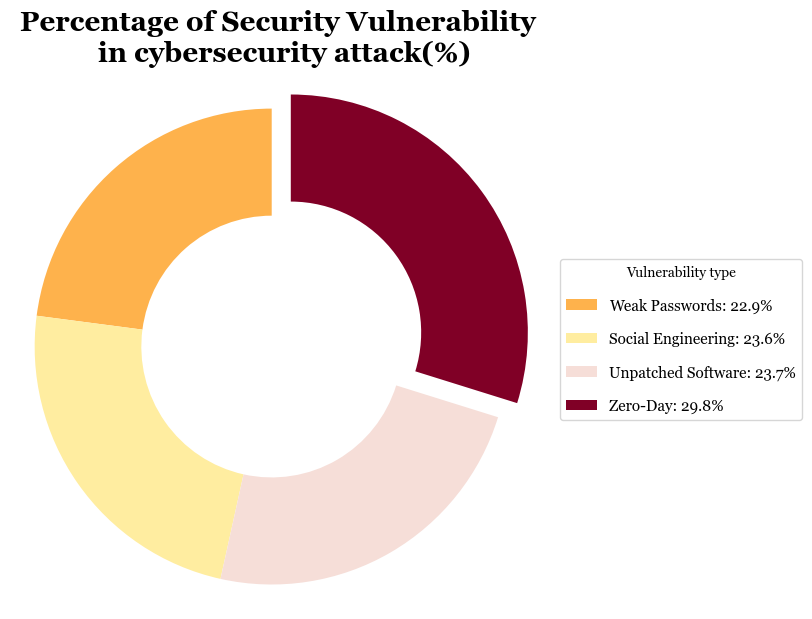

In [404]:
reasoncount=cyberdata['Security Vulnerability Type'].value_counts().sort_values()
labels = reasoncount.index.tolist()
sizes = reasoncount.values
plt.figure(figsize=(7,7))
colors = [ '#feb24c', '#ffeda0','#F6DED8','#800026'] 
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts = ax.pie(
    sizes,
    labels=None,  # ẩn nhãn trực tiếp trên lát
    colors=colors,
    startangle=90, 
    pctdistance=0.75,
    wedgeprops={'width': 0.45},
    explode=[0,0,0,0.1],
    textprops={ 'fontsize': 16}
)
ax.legend(
    wedges,
    [f"{label}: {size/sum(sizes):.1%}" for label, size in zip(labels, sizes)],
    title="Vulnerability type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),  # đưa sang phải
    labelspacing=1.2,
    fontsize=11
)
plt.title('Percentage of Security Vulnerability \n in cybersecurity attack(%)', fontsize=20, fontweight='bold')

plt.axis('equal')  # Đảm bảo hình tròn

plt.show()


## Number of attack according to Security vulnerability from 2015 to 2024

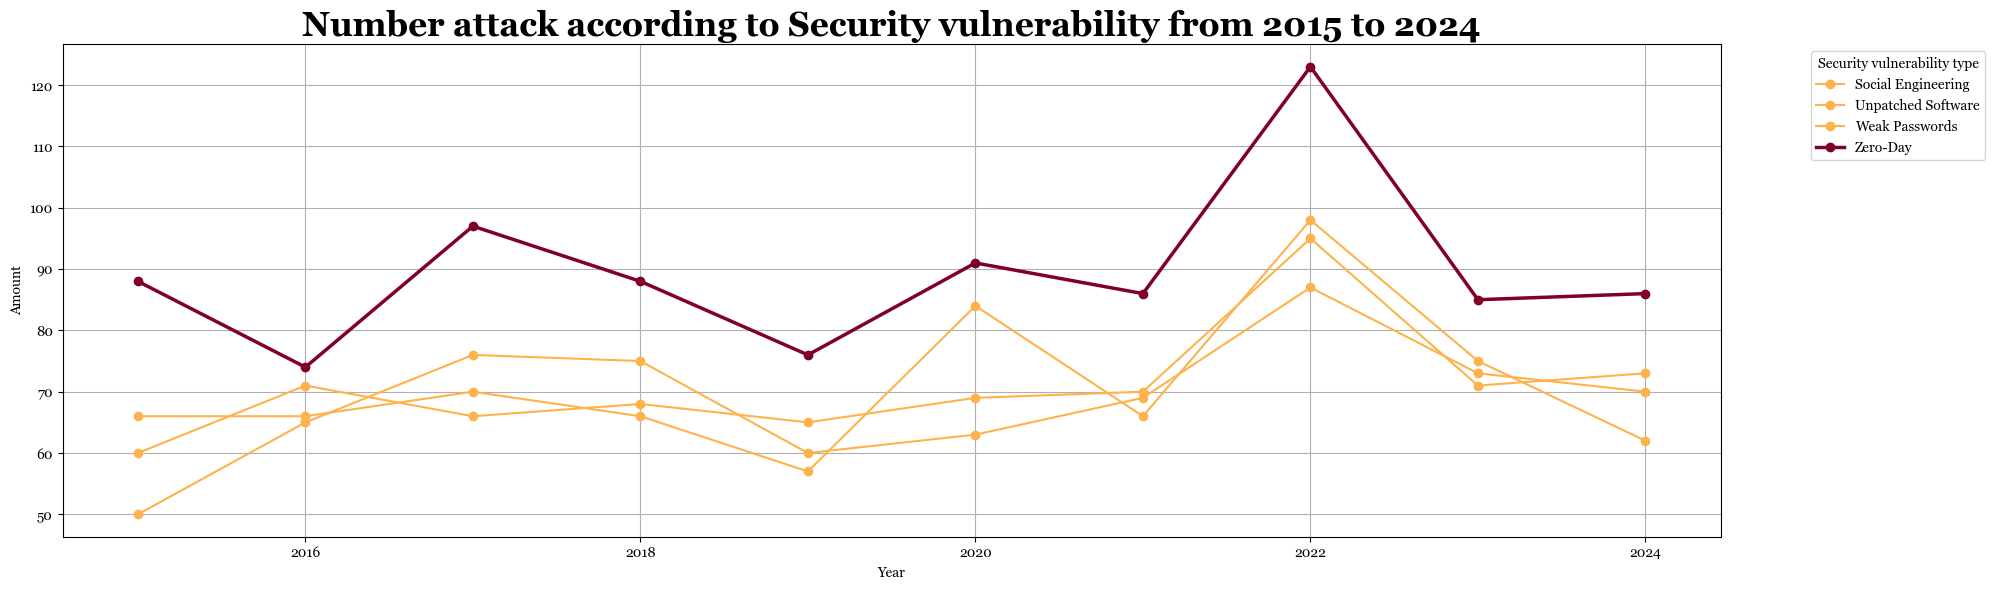

In [405]:

# Đếm số lượng lỗ hổng theo từng năm
vuln_by_year = cyberdata.groupby(['Year', 'Security Vulnerability Type']).size().reset_index(name='Count')

# Pivot để mỗi dòng là năm, mỗi cột là loại lỗ hổng
vuln_pivot = vuln_by_year.pivot(index='Year', columns='Security Vulnerability Type', values='Count').fillna(0)

# Vẽ biểu đồ đường
plt.figure(figsize=(20, 6))
for col in vuln_pivot.columns:
    if col == 'Zero-Day':
        plt.plot(vuln_pivot.index, vuln_pivot[col], marker='o', label=col, color='#800026', linewidth=2.5)
    else:
        plt.plot(vuln_pivot.index, vuln_pivot[col], marker='o', label=col,color ='#feb24c', linewidth=1.5)
plt.title('Number attack according to Security vulnerability from 2015 to 2024', fontsize=24, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend(title='Security vulnerability type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [406]:
vuln_pivot.columns

Index(['Social Engineering', 'Unpatched Software', 'Weak Passwords',
       'Zero-Day'],
      dtype='object', name='Security Vulnerability Type')

In [407]:
vuln_pivot

Security Vulnerability Type,Social Engineering,Unpatched Software,Weak Passwords,Zero-Day
Year,,,,
2015,60,66,50,88
2016,71,66,65,74
2017,66,70,76,97
2018,68,66,75,88
2019,65,57,60,76
2020,69,84,63,91
2021,70,66,69,86
2022,95,98,87,123
2023,71,75,73,85


## biểu đồ phòng thủ áp dụng cho từng loại lỗ hổng 

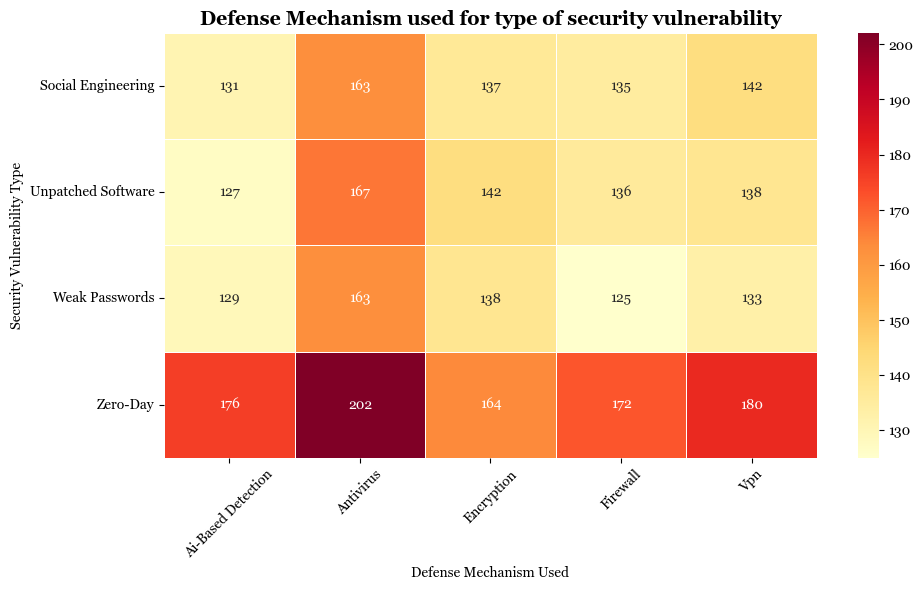

In [408]:
heatmap_data = cyberdata.groupby(['Security Vulnerability Type', 'Defense Mechanism Used']).size().unstack(fill_value=0)

# Vẽ heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap= 'YlOrRd' , linewidths=0.5)

plt.title('Defense Mechanism used for type of security vulnerability', fontsize=14, fontweight='bold')
plt.xlabel('Defense Mechanism Used')
plt.ylabel('Security Vulnerability Type')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## financial loss theo lỗ hổng

In [409]:

finan_los_type=cyberdata[['Financial Loss (in Million $)','Security Vulnerability Type']].groupby('Security Vulnerability Type').sum()

In [410]:
max_loss = finan_los_type['Financial Loss (in Million $)'].idxmax()
max_loss

'Zero-Day'

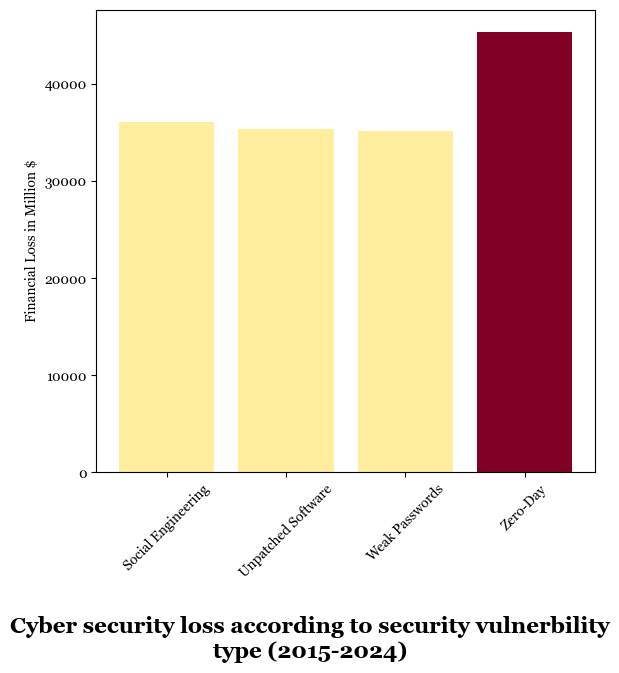

In [411]:
max_loss = finan_los_type['Financial Loss (in Million $)'].idxmax()

# Tạo danh sách màu: nếu index là cột cao nhất thì dùng màu khác, còn lại dùng màu mặc định
colors = ['#800026' if i == max_loss else'#ffeda0' for i in finan_los_type.index]

# Vẽ biểu đồ
plt.figure(figsize=(6,6))
bars = plt.bar(finan_los_type.index, finan_los_type['Financial Loss (in Million $)'], color=colors)
plt.figtext(0.5, -0.1, 'Cyber security loss according to security vulnerbility type (2015-2024)',
            wrap=True, horizontalalignment='center', fontsize=16, fontweight='bold')
plt.ylabel('Financial Loss in Million $')
plt.xticks(rotation=45, )
plt.tight_layout()

plt.show()


## Thiệt hại theo năm bởi lỗ hổng Zero-Day

In [412]:
filtered_data = cyberdata[cyberdata['Security Vulnerability Type'] == 'Zero-Day']
zero_day_loss_by_year = filtered_data.groupby('Year')['Financial Loss (in Million $)'].sum().reset_index()

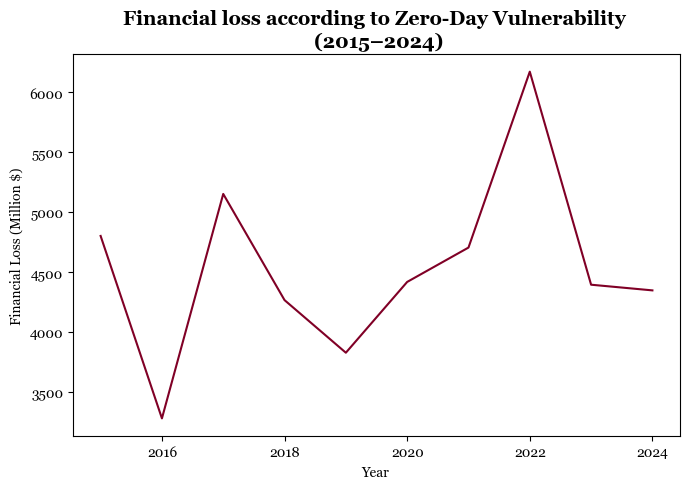

In [413]:


# Vẽ biểu đồ
plt.figure(figsize=(7,5))
bars = plt.plot(zero_day_loss_by_year['Year'], zero_day_loss_by_year['Financial Loss (in Million $)'], color='#800026')

plt.title('Financial loss according to Zero-Day Vulnerability \n (2015–2024)', fontsize=14, fontweight='bold')
plt.ylabel('Financial Loss (Million $)' )
plt.xlabel('Year ' )
plt.xticks()
plt.yticks()
plt.tight_layout()

plt.show()


In [414]:
finan_los_type.head()

,Financial Loss (in Million $)
Security Vulnerability Type,
Social Engineering,36081.93
Unpatched Software,35304.39
Weak Passwords,35065.83
Zero-Day,45347.59


## Number of attack caused by security vulnerability:Zero-Day according to Attack Type

In [415]:
filtered_data = cyberdata[cyberdata['Security Vulnerability Type'] == 'Zero-Day']
numbersecurity=filtered_data[['Security Vulnerability Type','Attack Type']].groupby('Attack Type').count()




In [416]:
numbersecurity 

,Security Vulnerability Type
Attack Type,
Ddos,136
Malware,158
Man-In-The-Middle,127
Phishing,201
Ransomware,126
Sql Injection,146


In [417]:
numbersecurity['Security Vulnerability Type']

Attack Type
Ddos                 136
Malware              158
Man-In-The-Middle    127
Phishing             201
Ransomware           126
Sql Injection        146
Name: Security Vulnerability Type, dtype: int64

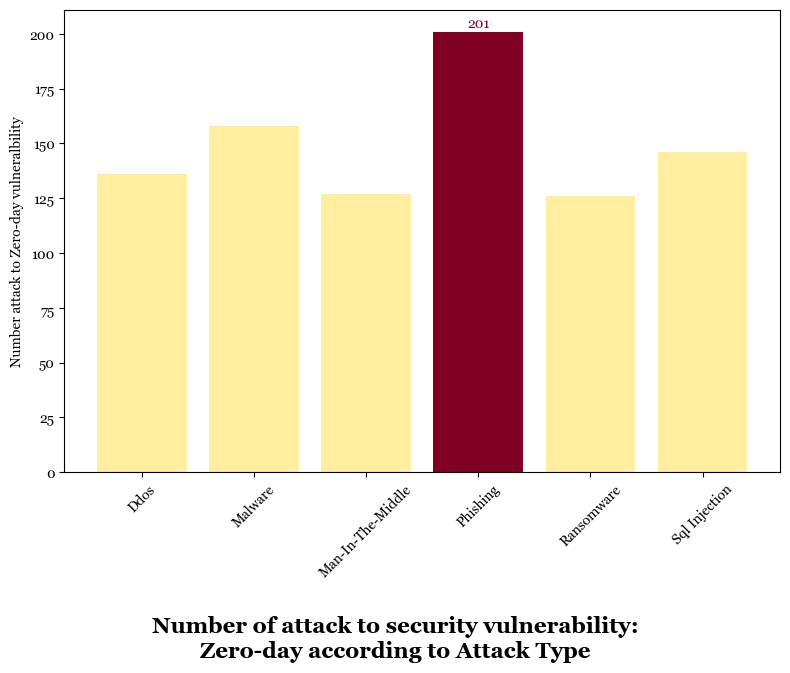

In [418]:


max_index = numbersecurity['Security Vulnerability Type'].idxmax()

colors = ['#800026' if i == max_index else '#ffeda0' for i in numbersecurity.index]

# Vẽ biểu đồ
plt.figure(figsize=(8,6))
bars = plt.bar(numbersecurity.index, numbersecurity['Security Vulnerability Type'], color=colors)
plt.figtext(0.5, -0.1, 'Number of attack to security vulnerability:\nZero-day according to Attack Type',
            wrap=True, horizontalalignment='center', fontsize=16, fontweight='bold')
plt.ylabel('Number attack to Zero-day vulneralbility')
plt.xticks(rotation=45, )
plt.tight_layout()


max_value = numbersecurity['Security Vulnerability Type'].max()
max_x = list(numbersecurity.index).index(max_index)  # vị trí theo thứ tự cột

# Hiển thị giá trị ngay trên đỉnh cột cao nhất
plt.text(max_x, max_value + 0.5, f'{max_value}', ha='center', va='bottom', fontsize=10,color='#800026')
plt.show()


## phần trăm phishing trong Zero-Day

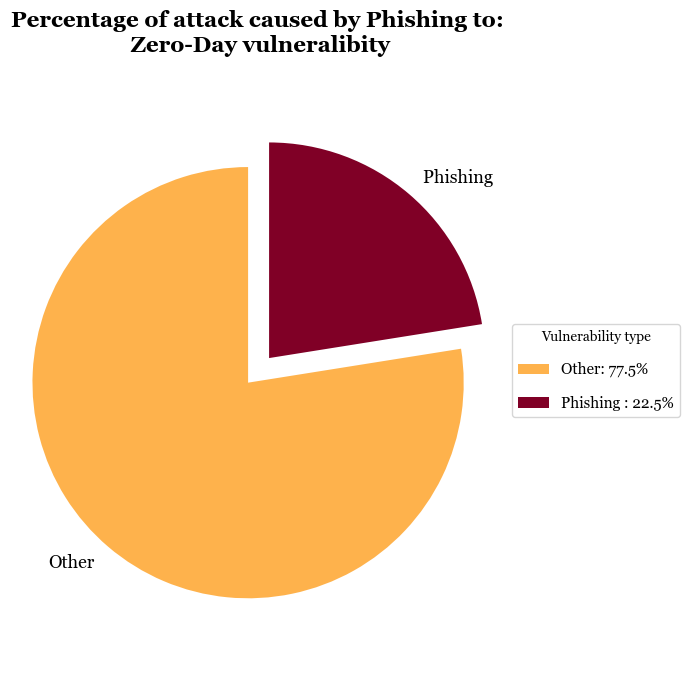

In [419]:


attack_counts = filtered_data['Attack Type'].value_counts().sort_values(ascending=False)

# Lấy số lượng Phishing và Other
phishing_count = attack_counts.get('Phishing', 0)
other_count = attack_counts.sum() - phishing_count

# Tạo dữ liệu cho biểu đồ
labels = ['Other', 'Phishing ']
sizes = [other_count, phishing_count]
colors = ['#feb24c', '#800026']  # màu đỏ đậm cho Phishing, đỏ nhạt cho phần còn lại

# Vẽ biểu đồ tròn
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts= ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=[0,0.15],
    startangle=90,
    textprops={'color': 'black', 'fontsize': 13},
   
)
ax.legend(
    wedges,
    [f"{label}: {size/sum(sizes):.1%}" for label, size in zip(labels, sizes)],
    title="Vulnerability type",
    loc="center left", 
    bbox_to_anchor=(1, 0.5),  # đưa sang phải
    labelspacing=1.2,
    fontsize=11)
# Tiêu đề
ax.set_title('Percentage of attack caused by Phishing to:\n Zero-Day vulneralibity',
             fontsize=16,fontweight='bold')

ax.axis('equal')  # đảm bảo hình tròn
plt.tight_layout()
plt.show()

In [420]:

attacktypethrtime=cyberdata[['Year','Attack Type']].groupby('Year').count()
attacktypethrtime

,Attack Type
Year,
2015,264
2016,276
2017,309
2018,297
2019,258
2020,307
2021,291
2022,403
2023,304


## Cơ cấu các cuộc tấn công theo các năm

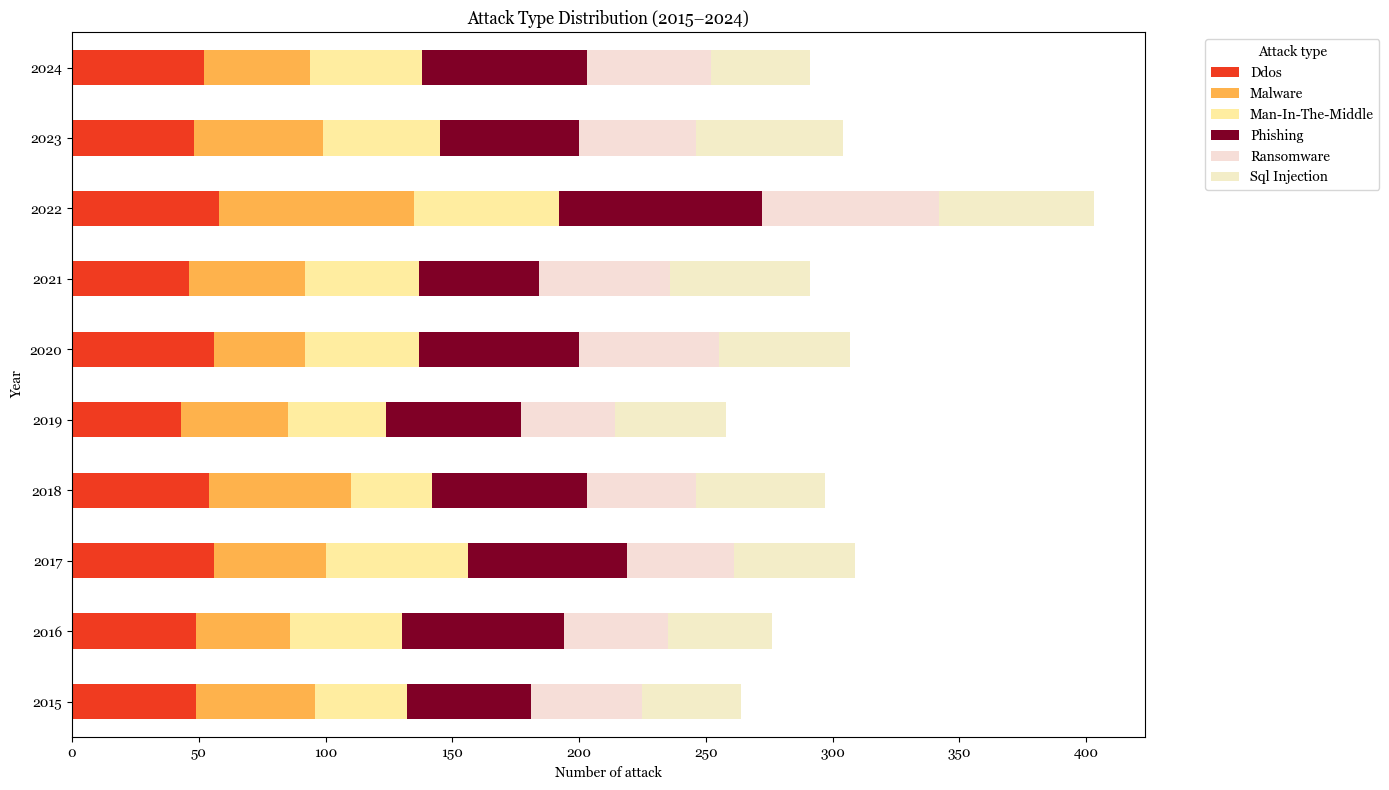

In [421]:

attack_counts = cyberdata.groupby(['Year', 'Attack Type']).size().unstack(fill_value=0)

# Sắp xếp theo năm
attack_counts = attack_counts.sort_index()
colors = ['#f03b20', '#feb24c', '#ffeda0', '#800026', '#F6DED8','#F3EDC8'] 
color_list = [colors[i] for i in range(len(attack_counts.columns))]

# Vẽ stacked horizontal bar chart
attack_counts.plot(
    kind='barh',
    stacked=True,
    figsize=(14, 8),
    color = color_list
)


# Chỉnh giao diện 
plt.xlabel('Number of attack',  )
plt.ylabel('Year')
plt.title('Attack Type Distribution (2015–2024)')
plt.legend(title='Attack type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
